In [2]:
import pandas as pd

from pathlib import Path

file_name = "finance_early_loan_repayment_prediction_dataset.xls"

data_path = Path(file_name)

print("Current dataset path:", data_path)

print("File exists:", data_path.exists())

df = pd.read_csv(data_path)

print("\nDataset loaded successfully!")

df.head()

Current dataset path: finance_early_loan_repayment_prediction_dataset.xls
File exists: True

Dataset loaded successfully!


,Loan_ID,Age,Employment_Status,Annual_Income,Credit_Score,Loan_Amount,Loan_Term_Months,Interest_Rate,Monthly_Payment,Savings_Balance,Missed_Payments,Automatic_Payment,Loan_Type,Early_Repayment
0,1,68.0,Part-time,211300.0,628.0,116286,48,14.21,2199,118122.0,2,Yes,Auto,No
1,2,66.0,Full-time,99549.0,707.0,58967,24,13.38,2218,15269.0,3,No,Auto,No
2,3,31.0,Full-time,184931.0,664.0,90631,60,7.47,362,88882.0,4,No,Education,No
3,4,59.0,Full-time,124434.0,585.0,44255,36,6.22,1467,102787.0,4,No,Business,Yes
4,5,72.0,Full-time,108950.0,612.0,48376,60,4.93,990,64234.0,4,Yes,Business,Yes


In [3]:
target_column = "Early_Repayment"

print("Target column:")

print(target_column)

print("\nTarget values:")

print(df[target_column].value_counts())

Target column:
Early_Repayment

Target values:
Early_Repayment
No     240
Yes    147
Name: count, dtype: int64


In [6]:
feature_columns = [
    "Age",
    "Employment_Status",
    "Annual_Income",
    "Credit_Score",
    "Loan_Amount",
    "Loan_Term_Months",
    "Interest_Rate",
    "Monthly_Payment",
    "Savings_Balance",
    "Missed_Payments",
    "Automatic_Payment",
    "Loan_Type"
]

X = df[feature_columns] 

y = df[target_column]  

print("Feature columns:") 

print(feature_columns)  

print("\nTarget column:") 

print(target_column)  

print("\nShape of X:")

print(X.shape) 

print("\nShape of y:")  
print(y.shape)

Feature columns:
['Age', 'Employment_Status', 'Annual_Income', 'Credit_Score', 'Loan_Amount', 'Loan_Term_Months', 'Interest_Rate', 'Monthly_Payment', 'Savings_Balance', 'Missed_Payments', 'Automatic_Payment', 'Loan_Type']

Target column:
Early_Repayment

Shape of X:
(387, 12)

Shape of y:
(387,)


In [7]:
print("Dataset shape:")

print(df.shape)

print("\nColumn names:")

print(df.columns.tolist())

display(df.head())

Dataset shape:
(387, 14)

Column names:
['Loan_ID', 'Age', 'Employment_Status', 'Annual_Income', 'Credit_Score', 'Loan_Amount', 'Loan_Term_Months', 'Interest_Rate', 'Monthly_Payment', 'Savings_Balance', 'Missed_Payments', 'Automatic_Payment', 'Loan_Type', 'Early_Repayment']


,Loan_ID,Age,Employment_Status,Annual_Income,Credit_Score,Loan_Amount,Loan_Term_Months,Interest_Rate,Monthly_Payment,Savings_Balance,Missed_Payments,Automatic_Payment,Loan_Type,Early_Repayment
0,1,68.0,Part-time,211300.0,628.0,116286,48,14.21,2199,118122.0,2,Yes,Auto,No
1,2,66.0,Full-time,99549.0,707.0,58967,24,13.38,2218,15269.0,3,No,Auto,No
2,3,31.0,Full-time,184931.0,664.0,90631,60,7.47,362,88882.0,4,No,Education,No
3,4,59.0,Full-time,124434.0,585.0,44255,36,6.22,1467,102787.0,4,No,Business,Yes
4,5,72.0,Full-time,108950.0,612.0,48376,60,4.93,990,64234.0,4,Yes,Business,Yes


In [8]:
print("Dataset information:")

df.info()

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 387 entries, 0 to 386
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            387 non-null    int64  
 1   Age                380 non-null    float64
 2   Employment_Status  380 non-null    object 
 3   Annual_Income      380 non-null    float64
 4   Credit_Score       380 non-null    float64
 5   Loan_Amount        387 non-null    int64  
 6   Loan_Term_Months   387 non-null    int64  
 7   Interest_Rate      387 non-null    float64
 8   Monthly_Payment    387 non-null    int64  
 9   Savings_Balance    379 non-null    float64
 10  Missed_Payments    387 non-null    int64  
 11  Automatic_Payment  387 non-null    object 
 12  Loan_Type          379 non-null    object 
 13  Early_Repayment    387 non-null    object 
dtypes: float64(5), int64(5), object(4)
memory usage: 42.5+ KB


In [9]:
print("Data types of each column:")  

print(df.dtypes)

Data types of each column:
Loan_ID                int64
Age                  float64
Employment_Status     object
Annual_Income        float64
Credit_Score         float64
Loan_Amount            int64
Loan_Term_Months       int64
Interest_Rate        float64
Monthly_Payment        int64
Savings_Balance      float64
Missed_Payments        int64
Automatic_Payment     object
Loan_Type             object
Early_Repayment       object
dtype: object


In [10]:
print("Missing values in each column:")  

print(df.isnull().sum())

Missing values in each column:
Loan_ID              0
Age                  7
Employment_Status    7
Annual_Income        7
Credit_Score         7
Loan_Amount          0
Loan_Term_Months     0
Interest_Rate        0
Monthly_Payment      0
Savings_Balance      8
Missed_Payments      0
Automatic_Payment    0
Loan_Type            8
Early_Repayment      0
dtype: int64


In [11]:
print("Number of duplicate rows:")  

print(df.duplicated().sum())

Number of duplicate rows:
7


In [12]:
df_clean = df.copy()  

print("Original dataset shape:")  

print(df_clean.shape)  

print("\nNumber of duplicate rows before cleaning:") 

print(df_clean.duplicated().sum())

Original dataset shape:
(387, 14)

Number of duplicate rows before cleaning:
7


In [54]:
df_clean = df_clean.drop_duplicates()  

print("Dataset shape after removing duplicate rows:") 

print(df_clean.shape) 

print("\nNumber of duplicate rows after cleaning:")  

print(df_clean.duplicated().sum())

Dataset shape after removing duplicate rows:
(380, 14)

Number of duplicate rows after cleaning:
0


In [14]:
print("Missing values before filling:")  

print(df_clean.isnull().sum())

Missing values before filling:
Loan_ID              0
Age                  7
Employment_Status    7
Annual_Income        7
Credit_Score         7
Loan_Amount          0
Loan_Term_Months     0
Interest_Rate        0
Monthly_Payment      0
Savings_Balance      7
Missed_Payments      0
Automatic_Payment    0
Loan_Type            7
Early_Repayment      0
dtype: int64


In [18]:
numeric_columns = [
    "Age",
    "Annual_Income",
    "Credit_Score",
    "Loan_Amount",
    "Loan_Term_Months",
    "Interest_Rate",
    "Monthly_Payment",
    "Savings_Balance",
    "Missed_Payments"
]

categorical_columns = [
     "Employment_Status",
    "Automatic_Payment",
    "Loan_Type"
]

In [19]:
for column in numeric_columns:
    median_value = df_clean[column].median()
    df_clean[column] = df_clean[column].fillna(median_value)

for column in categorical_columns:
    most_frequent_value = df_clean[column].mode()[0]
    df_clean[column] = df_clean[column].fillna(most_frequent_value)

print("Missing values after cleaning:")
print(df_clean.isnull().sum())

print("\nCleaned dataset preview:")  
display(df_clean.head()) 

Missing values after cleaning:
Loan_ID              0
Age                  0
Employment_Status    0
Annual_Income        0
Credit_Score         0
Loan_Amount          0
Loan_Term_Months     0
Interest_Rate        0
Monthly_Payment      0
Savings_Balance      0
Missed_Payments      0
Automatic_Payment    0
Loan_Type            0
Early_Repayment      0
dtype: int64

Cleaned dataset preview:


,Loan_ID,Age,Employment_Status,Annual_Income,Credit_Score,Loan_Amount,Loan_Term_Months,Interest_Rate,Monthly_Payment,Savings_Balance,Missed_Payments,Automatic_Payment,Loan_Type,Early_Repayment
0,1,68.0,Part-time,211300.0,628.0,116286,48,14.21,2199,118122.0,2,Yes,Auto,No
1,2,66.0,Full-time,99549.0,707.0,58967,24,13.38,2218,15269.0,3,No,Auto,No
2,3,31.0,Full-time,184931.0,664.0,90631,60,7.47,362,88882.0,4,No,Education,No
3,4,59.0,Full-time,124434.0,585.0,44255,36,6.22,1467,102787.0,4,No,Business,Yes
4,5,72.0,Full-time,108950.0,612.0,48376,60,4.93,990,64234.0,4,Yes,Business,Yes


In [20]:
feature_columns = [ 
    "Age",
    "Employment_Status",
    "Annual_Income",
    "Credit_Score",
    "Loan_Amount",
    "Loan_Term_Months",
    "Interest_Rate",
    "Monthly_Payment",
    "Savings_Balance",
    "Missed_Payments",
    "Automatic_Payment",
    "Loan_Type"
]  

target_column = "Early_Repayment"  

X = df_clean[feature_columns] 

y = df_clean[target_column] 

print("Feature columns:") 

print(feature_columns)  

print("\nTarget column:")  

print(target_column)

print("\nShape of X:")  

print(X.shape)  

print("\nShape of y:")  

print(y.shape)

Feature columns:
['Age', 'Employment_Status', 'Annual_Income', 'Credit_Score', 'Loan_Amount', 'Loan_Term_Months', 'Interest_Rate', 'Monthly_Payment', 'Savings_Balance', 'Missed_Payments', 'Automatic_Payment', 'Loan_Type']

Target column:
Early_Repayment

Shape of X:
(380, 12)

Shape of y:
(380,)


In [21]:
print("Target value counts before conversion:") 

print(y.value_counts())

Target value counts before conversion:
Early_Repayment
No     235
Yes    145
Name: count, dtype: int64


In [56]:
y = y.map({"No": 0, "Yes": 1}) 

print("Target value counts after conversion:")  

print(y.value_counts()) 

Target value counts after conversion:
Series([], Name: count, dtype: int64)


In [32]:
from sklearn.model_selection import train_test_split  

X_train, X_test, y_train, y_test = train_test_split(  
    X,  
    y,  
    test_size=0.20,  
    random_state=42,  
    stratify=y  
)  

print("Shape of X_train:")  

print(X_train.shape)  

print("\nShape of X_test:") 

print(X_test.shape)  

print("\nShape of y_train:")  

print(y_train.shape)  

print("\nShape of y_test:")  

print(y_test.shape)

Shape of X_train:
(304, 12)

Shape of X_test:
(76, 12)

Shape of y_train:
(304,)

Shape of y_test:
(76,)


In [33]:
print("Target distribution in y_train:")  

print(y_train.value_counts())  

print("\nTarget distribution in y_test:")  

print(y_test.value_counts())

Target distribution in y_train:
Early_Repayment
0    188
1    116
Name: count, dtype: int64

Target distribution in y_test:
Early_Repayment
0    47
1    29
Name: count, dtype: int64


In [34]:
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(

    transformers=[
        ("num", StandardScaler(), numeric_columns),

        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

In [35]:
X_train_preprocessed = preprocessor.fit_transform(X_train)

print("X_train preprocessing completed!")

X_test_preprocessed = preprocessor.transform(X_test)

print("X_test preprocessing completed!")

X_train preprocessing completed!
X_test preprocessing completed!


In [36]:
print("Summary of preprocessing shapes:") 

print("X_train before preprocessing:", X_train.shape)  

print("X_train after preprocessing:", X_train_preprocessed.shape) 

print("X_test before preprocessing:", X_test.shape) 

print("X_test after preprocessing:", X_test_preprocessed.shape) 

Summary of preprocessing shapes:
X_train before preprocessing: (304, 12)
X_train after preprocessing: (304, 20)
X_test before preprocessing: (76, 12)
X_test after preprocessing: (76, 20)


In [37]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_preprocessed, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [38]:
y_pred_logistic = logistic_model.predict(X_test_preprocessed)

print("Predictions completed successfully!")

Predictions completed successfully!


In [39]:
print("First 10 predictions:")

print(y_pred_logistic[:10])

First 10 predictions:
[0 0 1 0 0 0 0 0 0 1]


In [40]:
comparison_df = pd.DataFrame({ 
    "Actual": y_test.values,  
    "Predicted": y_pred_logistic 
}) 

display(comparison_df.head(10))

,Actual,Predicted
0,0,0
1,0,0
2,1,1
3,0,0
4,0,0
5,0,0
6,1,0
7,1,0
8,0,0
9,1,1


In [41]:
from sklearn.metrics import confusion_matrix

from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.metrics import accuracy_score

from sklearn.metrics import precision_score

from sklearn.metrics import recall_score

from sklearn.metrics import f1_score

from sklearn.metrics import classification_report

import matplotlib.pyplot as plt

In [48]:
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)

precision_logistic = precision_score(y_test, y_pred_logistic)

recall_logistic = recall_score(y_test, y_pred_logistic)

f1_logistic = f1_score(y_test, y_pred_logistic)

print("Logistic Regression Evaluation Metrics:")

print("Accuracy:", accuracy_logistic)

print("Precision:", precision_logistic)

print("Recall:", recall_logistic)

print("F1-score:", f1_logistic)

Logistic Regression Evaluation Metrics:
Accuracy: 0.7368421052631579
Precision: 0.6551724137931034
Recall: 0.6551724137931034
F1-score: 0.6551724137931034


In [42]:
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

print("Confusion Matrix:")

print(cm_logistic)

Confusion Matrix:
[[37 10]
 [10 19]]


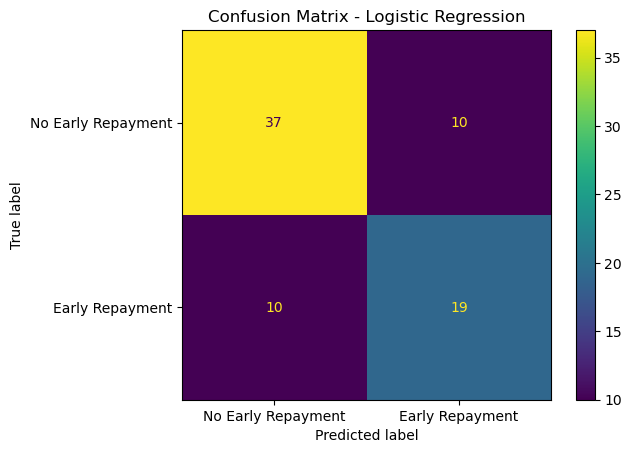

In [55]:
display_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["No Early Repayment", "Early Repayment"]
)

display_cm.plot()

plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [45]:
from sklearn.svm import SVC 

svm_model = SVC(random_state=42) 

svm_model.fit(X_train_preprocessed, y_train)  

print("SVM model trained successfully!")

y_pred_svm = svm_model.predict(X_test_preprocessed)

print("SVM predictions completed successfully!")

SVM model trained successfully!
SVM predictions completed successfully!


In [46]:
print("First 10 SVM predictions:")  

print(y_pred_svm[:10])

First 10 SVM predictions:
[0 0 0 0 0 0 0 0 0 1]


In [47]:
svm_comparison_df = pd.DataFrame({  
    "Actual": y_test.values,  
    "SVM_Predicted": y_pred_svm  
})  

display(svm_comparison_df.head(10))

,Actual,SVM_Predicted
0,0,0
1,0,0
2,1,0
3,0,0
4,0,0
5,0,0
6,1,0
7,1,0
8,0,0
9,1,1


In [49]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)

precision_svm = precision_score(y_test, y_pred_svm)

recall_svm = recall_score(y_test, y_pred_svm)

f1_svm = f1_score(y_test, y_pred_svm)

print("SVM Evaluation Metrics:")

print("Accuracy:", accuracy_svm)

print("Precision:", precision_svm)

print("Recall:", recall_svm)

print("F1-score:", f1_svm)

SVM Evaluation Metrics:
Accuracy: 0.6710526315789473
Precision: 0.5714285714285714
Recall: 0.5517241379310345
F1-score: 0.5614035087719298


In [50]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

print("Confusion Matrix - SVM:")

print(cm_svm)

Confusion Matrix - SVM:
[[35 12]
 [13 16]]


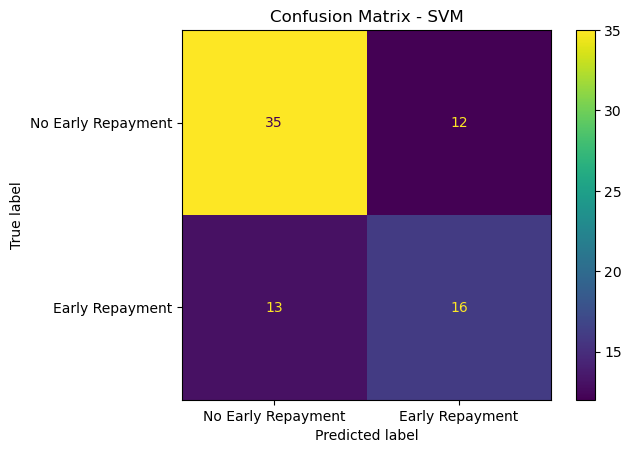

In [51]:
display_cm_svm = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["No Early Repayment", "Early Repayment"]
)

display_cm_svm.plot()

plt.title("Confusion Matrix - SVM")

plt.show()

In [52]:
model_comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM"],

    "Accuracy": [accuracy_logistic, accuracy_svm],

    "Precision": [precision_logistic, precision_svm],

    "Recall": [recall_logistic, recall_svm],

    "F1-score": [f1_logistic, f1_svm]
})

display(model_comparison_df)

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.736842,0.655172,0.655172,0.655172
1,SVM,0.671053,0.571429,0.551724,0.561404


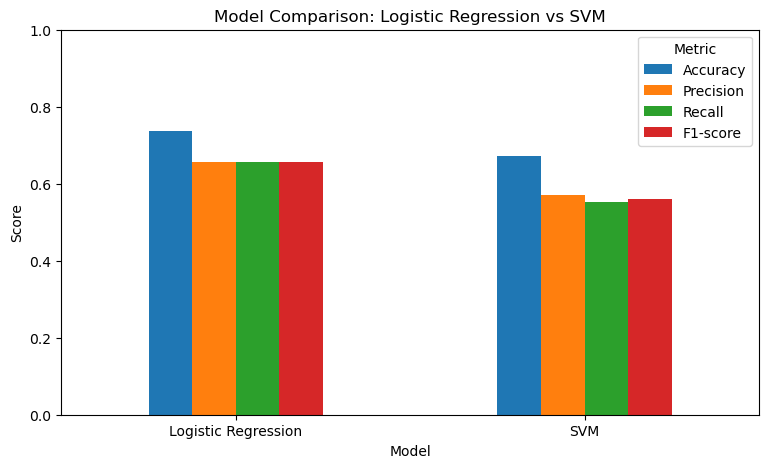

In [53]:
model_comparison_df.set_index("Model").plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Model Comparison: Logistic Regression vs SVM")

plt.xlabel("Model")

plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.legend(title="Metric")

plt.show()

Compare the results and interpret them:
1. Which model performed better?
Based on the evaluation results, Logistic Regression performed better than SVM.

   Logistic Regression:
- Accuracy: 0.7368
- Precision: 0.6552
- Recall: 0.6552
- F1-score: 0.6552

  SVM:
- Accuracy: 0.6711
- Precision: 0.5714
- Recall: 0.5517
- F1-score: 0.5614
Logistic Regression has higher accuracy, precision, recall, and F1-score, so it is the better model for this dataset.

2. Which metric is most important for your business problem?

   For this business problem, recall is very important because the financial institution wants to identify customers who are likely to repay their loans early. Logistic Regression recall is 0.6552, meaning it correctly identified about 65.52% of actual early repayment customers.


3. What do false positives and false negatives mean in your dataset?

   A false positive means the model predicted that a customer would repay early, but the customer actually did not repay early. A false negative means the model predicted that a customer would not repay early, but the customer actually did repay early.
   
4. What is one possible limitation or bias in your model?

   One limitation is that the model may be biased if the dataset is not balanced or does not represent all types of borrowers. For example, if one repayment class appears more often, the model may learn that pattern more strongly.
 
5. Why should human judgment still be used?

   Human judgment is still needed because even the better model only had an F1-score of 0.6552, so it still made mistakes. Financial decisions should not rely only on model predictions.

In [57]:
from pathlib import Path

output_folder = Path("outputs")

output_folder.mkdir(exist_ok=True)

print("Output folder is ready.")

Output folder is ready.


In [58]:
cleaned_data_path = output_folder / "cleaned_finance_dataset.csv"

df_clean.to_csv(cleaned_data_path, index=False)

print("Cleaned dataset saved successfully.")

print(cleaned_data_path)

Cleaned dataset saved successfully.
outputs/cleaned_finance_dataset.csv


In [59]:
model_results_path = output_folder / "model_comparison_results.csv"

model_comparison_df.to_csv(model_results_path, index=False)

print("Model comparison results saved successfully.")

print(model_results_path)

Model comparison results saved successfully.
outputs/model_comparison_results.csv


In [61]:
classification_output_path = output_folder / "classification_outputs.csv" 

classification_output_df.to_csv(classification_output_path, index=False) 

print("Classification outputs saved successfully.")  

print(classification_output_path) 

Classification outputs saved successfully.
outputs/classification_outputs.csv
